In [70]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import sklearn.linear_model



In [103]:
# Load the dataset
df = pd.read_csv('gdp_happiness_expectancy_official_2026.csv')
df.head(10)


,Country,GDP_Per_Capita_USD,Life_Satisfaction,Life_Expectancy_Years,Continent,Data_Year
0,Luxembourg,138757,7.12,83.2,Europe,2026
1,Ireland,112356,6.89,82.8,Europe,2026
2,Switzerland,108256,6.94,84.3,Europe,2026
3,Singapore,94897,6.52,84.1,Asia,2026
4,Norway,89684,7.26,83.5,Europe,2026
5,Iceland,86485,7.52,83.6,Europe,2026
6,United States,86173,6.72,79.3,North America,2026
7,Denmark,71214,7.52,81.9,Europe,2026
8,Qatar,69720,6.48,81.5,Asia,2026
9,Finland,68860,7.76,82.4,Europe,2026


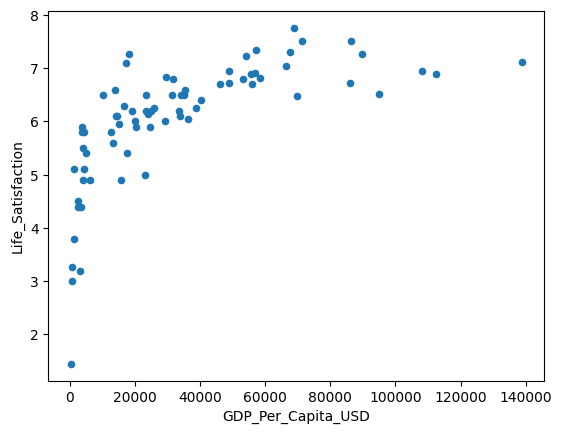

In [88]:
x= df['GDP_Per_Capita_USD'].values
y = df['Life_Satisfaction'].values
df.plot(kind = 'scatter',x = 'GDP_Per_Capita_USD', y = 'Life_Satisfaction')
plt.show()

In [89]:
#taking log of gdp
log_gdp = np.log(df['GDP_Per_Capita_USD'].values)
df['Log_GDP'] = log_gdp
features = ['Log_GDP', 'Social_Support', 'Freedom_To_Make_Choices', 'Corruption_Perception']


print("Raw GDP:",df['GDP_Per_Capita_USD'].values[:5])
print("Log GDP:", log_gdp[:5])

Raw GDP: [138757 112356 108256  94897  89684]
Log GDP: [11.84047948 11.62942768 11.59225407 11.46054737 11.40404766]


In [91]:
#Model-1 Life Satisfaction = θ₀ + θ₁ * log(GDP)+ ( * Social_Support) + (θ₃ * Freedom) + (θ₄ * Corruption)
y_satisfaction = df['Life_Satisfaction'].values
# sklearn expects X to be 2D (rows x columns), so we reshape
# from shape (68,) to shape (68, 1)
X = log_gdp.reshape(-1, 1)
# Create the model and fit it to our data
model1 = sklearn.linear_model.LinearRegression()
model1.fit(X, y_satisfaction)
# theta_0 is the intercept, theta_1 is the slope
theta0 = model1.intercept_
theta1 = model1.coef_[0]
print(f"θ₀ (intercept) = {theta0:.4f}")
print(f"θ₁ (slope)     = {theta1:.4f}")
print(f"Model: Life_Satisfaction = {theta0:.4f} + {theta1:.4f} * log(GDP)")
print(f"R² score = {model1.score(X, y_satisfaction):.4f}")



θ₀ (intercept) = -1.5609
θ₁ (slope)     = 0.7720
Model: Life_Satisfaction = -1.5609 + 0.7720 * log(GDP)
R² score = 0.7674


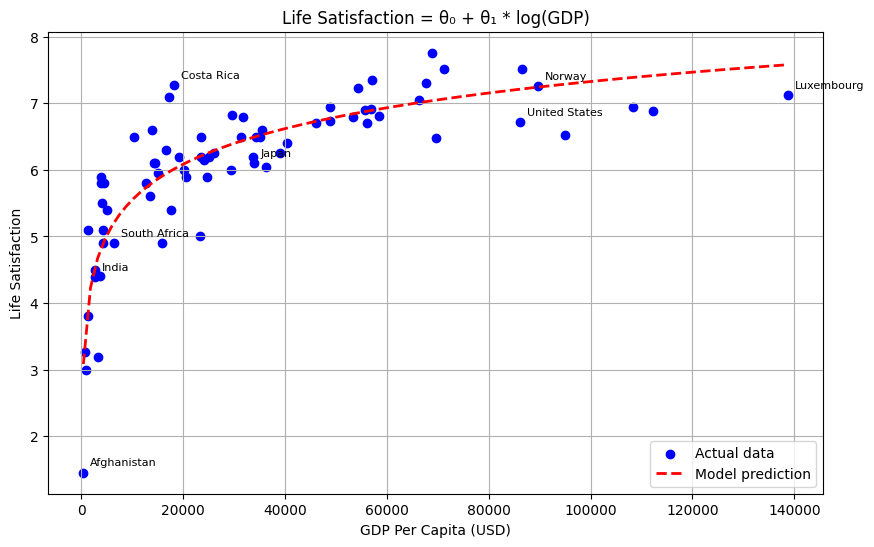

In [ ]:
#Plot Model1
plt.figure(figsize=(10, 6))
plt.scatter(df['GDP_Per_Capita_USD'], y_satisfaction, color='blue', label='Actual data')
# Model prediction curve

gdp_range = np.linspace(df['GDP_Per_Capita_USD'].min(), df['GDP_Per_Capita_USD'].max(), 100)
predicted_satisfaction = theta0 + theta1 * np.log(gdp_range)
plt.plot(gdp_range, predicted_satisfaction, color='red', linestyle='--', linewidth=2, label='Model prediction')
# Add country labels
highlight = ['India', 'United States', 'Norway', 'Afghanistan', 
             'Japan', 'Luxembourg', 'Costa Rica', 'South Africa']
for i in range(len(df)):
    if df['Country'].values[i] in highlight:
        plt.annotate(
            df['Country'].values[i],
            (df['GDP_Per_Capita_USD'].values[i], y_satisfaction[i]),
            fontsize=8,
            textcoords='offset points',
            xytext=(5, 5)
        )
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Life Satisfaction')
plt.title('Life Satisfaction = θ₀ + θ₁ * log(GDP)')
plt.legend()
plt.grid(True)
plt.show()





In [99]:
#Prediciton of some country's life satisfaction
new_gdp = 38933
new_X =   np.log(np.array([[new_gdp]]))
predicted = model1.predict(new_X)

print("Predicted Life Satisfaction: ", predicted[0])



Predicted Life Satisfaction:  6.598737350838598


In [93]:
#Model2 - Life Expectancy =  θ₀ + θ₁ * log(GDP)

y_expectancy = df['Life_Expectancy_Years'].values
model2 = sklearn.linear_model.LinearRegression()
model2.fit(X, y_expectancy)
theta0_exp = model2.intercept_
theta1_exp = model2.coef_[0]

print(f"θ₀ (intercept) = {theta0_exp:.4f}")
print(f"θ₁ (slope)     = {theta1_exp:.4f}")
print(f"Model: Life_Expectancy = {theta0_exp:.4f} + {theta1_exp:.4f} * log(GDP)")
print(f"R^2 score = {model2.score(X,y_expectancy):.4f}")





θ₀ (intercept) = 41.8446
θ₁ (slope)     = 3.6747
Model: Life_Expectancy = 41.8446 + 3.6747 * log(GDP)
R^2 score = 0.7652


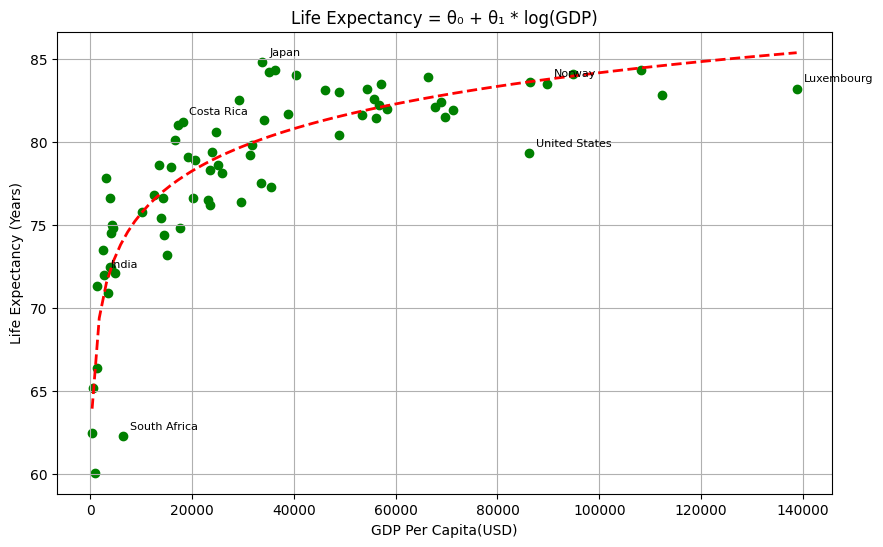

In [96]:
#Plot Model-2
predicted_expectancy = theta0_exp + theta1_exp*np.log(gdp_range)
plt.figure(figsize=(10, 6))
plt.scatter(df['GDP_Per_Capita_USD'], y_expectancy, color='green', label='Actual data')
plt.plot(gdp_range, predicted_expectancy, color='red', linestyle='--', linewidth=2, label='Model prediction')

highlight = ['India', 'United States', 'Norway', 
             'Japan', 'Luxembourg', 'Costa Rica', 'South Africa']
for i in range(len(df)):
    if df['Country'].values[i] in highlight:
        plt.annotate(
            df['Country'].values[i],
            (df['GDP_Per_Capita_USD'].values[i], y_expectancy[i]),
            fontsize=8,
            textcoords='offset points',
            xytext=(5, 5)
        )

plt.xlabel('GDP Per Capita(USD)')
plt.ylabel('Life Expectancy (Years)')
plt.title('Life Expectancy = θ₀ + θ₁ * log(GDP)')
plt.grid(True)
plt.show()





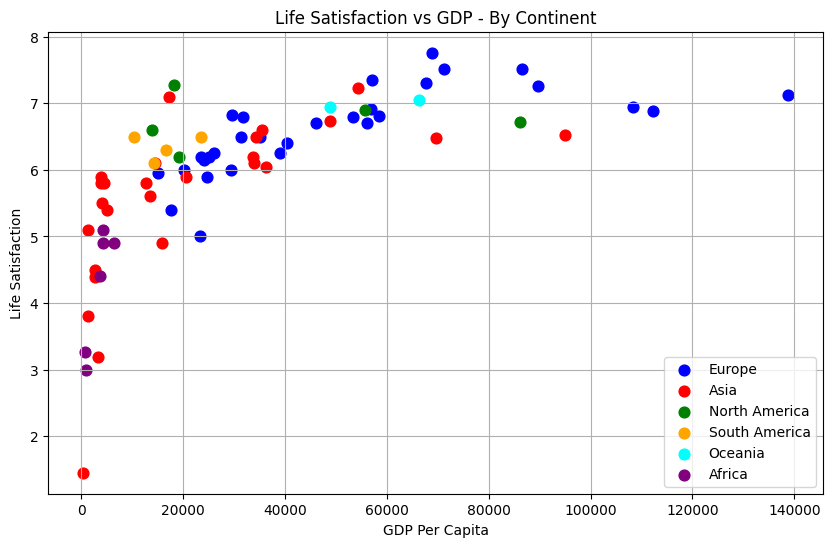

In [98]:
#PLOT - CONTINENT WISE ANALSYSIS
continent_colors = {
    'Europe': 'blue',
    'Asia': 'red',
    'North America': 'green',
    'South America': 'orange',
    'Oceania': 'cyan',
    'Africa': 'purple'
}

plt.figure(figsize=(10, 6))
for continent, color in continent_colors.items():
    mask = df['Continent'] == continent
    plt.scatter(df.loc[mask, 'GDP_Per_Capita_USD'], 
                df.loc[mask, 'Life_Satisfaction'],
                color=color, label=continent, s=60)

plt.legend()
plt.xlabel('GDP Per Capita')
plt.ylabel('Life Satisfaction')
plt.title('Life Satisfaction vs GDP - By Continent')
plt.grid(True)
plt.show()


In [100]:
#Prediciton of some country's life expectancy
new_gdp = 38933
new_X =   np.log(np.array([[new_gdp]]))
predicted = model2.predict(new_X)

print("Predicted Life Expectancy: ", predicted[0])


Predicted Life Expectancy:  80.6845230783267
